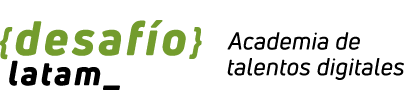

<center><h1> <font color='green'>Regresión lineal con Python</font></h1></center>

1. Importamos las librerías necesarias.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

#Librerías de machine learning
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

2. Cargamos los datos de prueba. Utilizamos el dataset **diabetes** para obtener datos de esta enfermedad. Vamos a obtener por separado las características ('diabetes_X') y las etiquetas ('diabetes_y'). Notemos que **diabetes_X** es una lista de listas, con 10 valores cada una.

In [19]:
data = load_diabetes(return_X_y= False, as_frame=True, scaled = False)
data

{'data':       age  sex   bmi      bp     s1     s2    s3    s4      s5     s6
 0    59.0  2.0  32.1  101.00  157.0   93.2  38.0  4.00  4.8598   87.0
 1    48.0  1.0  21.6   87.00  183.0  103.2  70.0  3.00  3.8918   69.0
 2    72.0  2.0  30.5   93.00  156.0   93.6  41.0  4.00  4.6728   85.0
 3    24.0  1.0  25.3   84.00  198.0  131.4  40.0  5.00  4.8903   89.0
 4    50.0  1.0  23.0  101.00  192.0  125.4  52.0  4.00  4.2905   80.0
 ..    ...  ...   ...     ...    ...    ...   ...   ...     ...    ...
 437  60.0  2.0  28.2  112.00  185.0  113.8  42.0  4.00  4.9836   93.0
 438  47.0  2.0  24.9   75.00  225.0  166.0  42.0  5.00  4.4427  102.0
 439  60.0  2.0  24.9   99.67  162.0  106.6  43.0  3.77  4.1271   95.0
 440  36.0  1.0  30.0   95.00  201.0  125.2  42.0  4.79  5.1299   85.0
 441  36.0  1.0  19.6   71.00  250.0  133.2  97.0  3.00  4.5951   92.0
 
 [442 rows x 10 columns],
 'target': 0      151.0
 1       75.0
 2      141.0
 3      206.0
 4      135.0
        ...  
 437    178.0
 438

In [20]:
df = pd.DataFrame(data.frame)
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0,178.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0,104.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0


In [22]:
diabetes_X, diabetes_y = load_diabetes(return_X_y=True, as_frame=True, scaled = False)

In [ ]:
diabetes_X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0
...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0


In [ ]:
diabetes_y

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


3. Aplicamos los pasos descritos.

  a) **División:** dividimos los datos en conjuntos de entrenamiento y prueba utilizando la función train_test_split. **diabetes_X** son las características, **diabetes_y** son las etiquetas, **test_size=0.3** indica que el 30% de los datos se utilizará para el conjunto de prueba, y **random_state=123** se utiliza para establecer una semilla aleatoria para la reproducibilidad de la división.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(diabetes_X, diabetes_y, test_size= 0.3, random_state=123)

> b) **Creación y entrenamiento:** creamos una instancia del objeto de regresión lineal (regr) utilizando **linear_model.LinearRegression()**. Luego, entrenamos el modelo utilizando los datos de entrenamiento llamando al método **fit()** del objeto **regr**


In [4]:
regr = LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

> c) **Predicción:** Realizamos la predicción utilizando los datos de prueba ('X_test') llamando al método **predict** del objeto **regr**. Imprimiremos, a partir de esto, los coeficientes del modelo ('regr.coef_')

In [5]:
y_pred = regr.predict(X_test)
print('Coeficientes: \n', regr.coef_)

Coeficientes: 
 [ 3.79716380e-02 -2.48944903e+01  5.80779568e+00  9.66480080e-01
 -1.17677553e+00  7.39338796e-01  6.13120867e-01  1.14352814e+01
  6.23562688e+01  4.24064740e-01]




> d) **Evaluación:** Evaluamos el modelo calculando el error cuadrado medio



In [6]:
print('\n Error cuadrado medio: %.2f' % mean_squared_error(y_test, y_pred))


 Error cuadrado medio: 2926.82


In [7]:
print('\n Coeficiente de Determinación (R2): %.2f' % r2_score(y_test, y_pred))


 Coeficiente de Determinación (R2): 0.51


Podemos verificar visualmente algunas de nuestras predicciones.

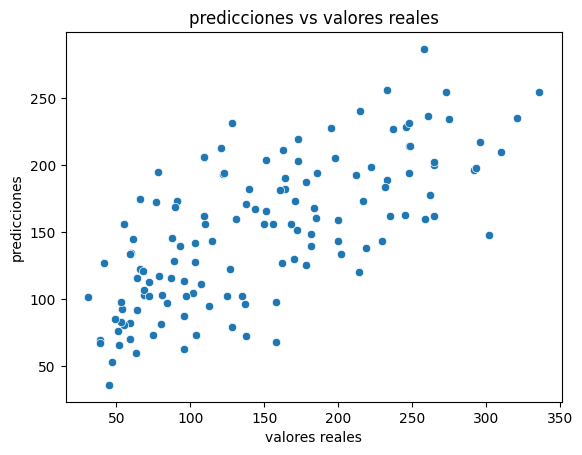

In [27]:
sns.scatterplot(x= y_test, y= y_pred)
plt.xlabel("valores reales")
plt.ylabel("predicciones")
plt.title("predicciones vs valores reales")
plt.show()